---
title: "Shock Absorber"
subtitle: "Bayesian Inference"
format: 
    html: 
        toc: true
execute: 
    enabled: false
code-annotations: hover
bibliography: "../../references.bib"
jupyter: python3
---

In this example we use the DIRT algorithm characterise the posterior distribution associated with a model of the time to failure for a shock absorber. As part of the example, we compare the performance of a standard functional tensor train (FTT) approximation, and extended FTT (EFTT) approximations in which the reduced bases are constructed using the proper orthogonal decomposition and adaptive cross approximation.

# Problem Setup

We consider the problem of estimating the parameters of a model of the time to failure for a type of shock absorber. For further information on the model, see @Dolgov2020 and the references therein.

We will use an accelerated failure time Weibull regression model, in which the density of the distance to failure of a given shock absorber is given by

$$
f(t | \theta_{1}, \theta_{2}) = \frac{\theta_{2}}{\theta_{1}}\left(\frac{t}{\theta_{1}}\right)^{\theta_{2}-1}\exp\left(-\left(\frac{t}{\theta_{1}}\right)^{\theta_{2}}\right),
$$

where $\theta_{1} >0$ is a scale parameter and $\theta_{2} > 0$ is a shape parameter. The scale parameter, $\theta_{1}$, depends on a set of $D$ covariates, $\boldsymbol{x} := [x_{1}, x_{2}, \dots, x_{D}]^{\top}$ (which are specific to each shock absorber) through the standard logarithmic link function:

$$
\theta_{1}(\boldsymbol{\beta}) = \exp\left(\beta_{0} + \sum_{i=1}^{D}\beta_{i}x_{i}\right),
$$

where $\boldsymbol{\beta} := [\beta_{0}, \beta_{1}, \dots, \beta_{D}]^{\top}$ denote a set of unknown parameters.

## Likelihood Function

To estimate the unknown parameters, we use a dataset of 38 failure distances, $\boldsymbol{t} := [t_{1}, t_{2}, \dots, t_{38}]^{\top}$, some of which are subject to right censoring. We assume that these measurements are independent, which means that the likelihood takes the form

$$
\mathcal{L}(\boldsymbol{\beta}, \theta_{2}; \boldsymbol{t}) = \prod_{i=1}^{38} P(t_{i} | \theta_{1}(\boldsymbol{\beta}), \theta_{2}),
$$

where 

$$
P(t_{i} | \theta_{1}, \theta_{2}) = \begin{cases}
    f(t_{i} | \theta_{1}, \theta_{2}), & \textrm{if } t_{i} \textrm{ is not censored}, \\
    \exp\left(-\left(\frac{t_{i}}{\theta_{1}}\right)^{\theta_{2}}\right), & \textrm{if } t_{i} \textrm{ is censored}.
\end{cases}
$$

The value for the right censored case is the probability that the failure time is greater than or equal to the observed value.

## Prior Density

As a prior, we use a normal-gamma density [see, *e.g.*, @Koch2007], which takes the form 

$$
\pi_{0}(\boldsymbol{\beta}, \theta_{2}) \propto \theta_{2}^{D/2+\alpha} \exp(-\gamma\theta_{2}) \prod_{i=0}^{D} \exp\left(-\frac{\theta_{2}(\beta_{i}-m_{i})^{2}}{2\sigma_{i}^{2}}\right),
$$

where $\gamma = 2.2932$, $\alpha = 6.8757$, $m_{0} = \log(30796)$, $m_{1} = \cdots = m_{D} = 0$, $\sigma_{0}^{2} = 0.1563$, and $\sigma_{1} = \cdots = \sigma_{D} = 1$.

Note that, with this choice for prior, the marginal density for $\theta_{2}$ is a gamma density; that is, $\theta_{2} \sim \mathrm{Gamma}(\gamma, \alpha)$. The conditional density for each coefficient $\beta_{i}$ is a normal density with a variance depending on $\theta_{2}$; that is, $\beta_{i} | \theta_{2} \sim \mathcal{N}(m_{i}, \sigma^{2}_{i}/\theta_{2})$.

# Implementation in $\texttt{deep\_tensor}$

We begin by importing the relevant libraries and reading in the failure distance data.

In [1]:
import math
from pathlib import Path

from matplotlib import pyplot as plt
import torch
from torch import Tensor

import deep_tensor as dt

from examples.plotting import add_arrows, set_plot_style
from examples.shock import GammaNormalMapping, load_shock_data

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.set_default_device(device)
torch.manual_seed(0)

plot_path = Path().parent.joinpath("plots")
set_plot_style()

In [3]:
data = load_shock_data(device)
failure_dists, censored = data.failure_dists, data.censored

Next, we define the $\alpha$ and $\gamma$ coefficients associated with the prior, as well as a function which evaluates the negative logarithm of the unnormalised posterior density.

In [ ]:
alpha = torch.tensor(6.8757)
gamma = torch.tensor(2.2932)

In [ ]:
def _eval_neglogpost(params: Tensor, xs: Tensor) -> Tensor:
    """Evaluates the negative logarithm of the (unnormalised) posterior 
    density.
    """

    bs, t2s = params[:, :-1], params[:, -1:]                            # <1>
    bxs = torch.sum(bs[:, 1:, None] * xs.T[None, :, :], dim=1)
    t1s = torch.exp(bs[:, :1] + bxs)

    neglogliks = (                                                      # <2>
        -torch.log(t2s / t1s[:, ~data.censored]) 
        - (t2s - 1.0) * torch.log(failure_dists[~censored] / t1s[:, ~censored]) 
        + (failure_dists[~censored] / t1s[:, ~censored]) ** t2s
    ).sum(dim=1)
    neglogliks += (                                                     # <3>
        (failure_dists[censored] / t1s[:, censored]) ** t2s
    ).sum(dim=1)

    neglogpris = (                                                      # <4>
        - (0.5*D + alpha) * t2s.log().flatten()
        + gamma * t2s.flatten()
        + 0.5 * torch.sum(t2s * (bs-ms)**2 / sds**2, dim=1)
    )
    
    neglogposts = neglogliks + neglogpris
    return neglogposts

1. Extract parameters and compute $\theta_{1}$ values
2. Add contribution of uncensored failure times to the negative log-likelihood function
3. Add contribution of censored failure times to the negative log-likelihood function
4. Evaluate the negative log-prior density

Finally, we define some options that will be common to all DIRT approximations constructed in our numerical experiments.

In [ ]:
eftt_pod_options = dt.EFTTOptions(fibre_method="random", tol_svd=1e-2, num_snapshots=50)
eftt_aca_options = dt.EFTTOptions(fibre_method="aca", tol_aca=1e-3, num_aca=100)

basis = dt.Lagrange1(num_elems=29)
reference = dt.GaussianReference()
bridge = dt.SingleLayer()
dirt_options = dt.DIRTOptions(verbose=0)

## (E)FTT Comparison: Varying Dimensions

We begin by varying the number of covariates, $D$, which has the effect of changing the dimension of the posterior (which is given by $D+2$), and comparing the accuracy of DIRT approximations to the posterior constructed using:

 - a standard FTT approximation;
 - an EFTT approximation with reduced bases constructed using the proper orthogonal decomposition (POD); and
 - an EFTT approximation with reduced bases constructed using adaptive cross approximation (ACA).

In [ ]:
ftts = ["FTT", "EFTT (POD)", "EFTT (ACA)"]

tt_options = dt.TTOptions(tt_method="amen", max_als=2, init_rank=8, verbose=0)

In [ ]:
Ds = torch.tensor([2, 4, 6, 8, 10, 12, 14]) 

num_replications = 10
num_samples = 5000

dhells = torch.zeros((len(Ds), num_replications, len(ftts)))
evals = torch.zeros_like(dhells)
max_tuckers = torch.zeros_like(dhells)

In [ ]:
for i, D in enumerate(Ds):

    D = int(D)
    dim = D + 2

    ms = torch.zeros(D+1)                                                   # <1>
    ms[0] = math.log(30796)
    sds = torch.ones(D+1)
    sds[0] = math.sqrt(0.1563)

    bounds = torch.zeros(D+2, 2)                                            # <2>
    bounds[:-1] = torch.vstack((ms - 3.0*sds, ms + 3.0*sds)).T 
    bounds[-1] = torch.tensor([1e-8, 13.0])

    preconditioner = GammaNormalMapping(
        reference, bounds, 
        alpha, gamma, 
        ms, sds, dim
    )

    for j in range(num_replications):
        
        covariate_shape = (failure_dists.numel(), D)                        # <3>
        xs = torch.randn(covariate_shape) / D
        eval_neglogpost = lambda params: _eval_neglogpost(params, xs)
        target_func = dt.TargetFunc(eval_neglogpost)

        rs = reference.random(n=num_samples, d=dim)                          # <4>

        for k, ftt_name in enumerate(ftts):

            tt = dt.TT(tt_options)
            if ftt_name == "FTT":
                ftt = dt.FTT(basis, tt)
            elif ftt_name == "EFTT (POD)":
                ftt = dt.EFTT(basis, tt, eftt_pod_options)
            elif ftt_name == "EFTT (ACA)":
                ftt = dt.EFTT(basis, tt, eftt_aca_options)
            dirt = dt.DIRT(
                target_func, preconditioner, ftt, bridge, 
                options=dirt_options
            )

            samples_dirt, neglogposts_dirt = dirt.eval_irt(rs)              # <5>
            neglogpost_true = eval_neglogpost(samples_dirt)                 # <6>
            dhell = dt.estimate_dhell(neglogposts_dirt, neglogpost_true)    # <7>

            dhells[i][j][k] = dhell 
            evals[i][j][k] = dirt.num_eval_construction
            if isinstance(dirt._sirts[0]._ftt, dt.EFTT):
                max_tuckers[i][j][k] = dirt._sirts[0]._ftt._basis_dims.max()

1. Define (dimension-dependent) means and standard deviations of $\beta$ coefficients
2. Define bounds for parameters
3. Sample a new set of covariates from a (rescaled) Gaussian and define a function that evaluates the associated negative log-posterior density
4. Generate a new set of samples from the reference density
5. Apply the inverse Rosenblatt transport to the samples from the reference such that they are distributed acccording to the current DIRT approximation to the posterior
6. Evaluate the negative logarithm of the true (unnormalised) posterior density
7. Estimate the Hellinger distance between the posterior and the DIRT approximation

We can now plot the results; these are shown in @fig-dimension.

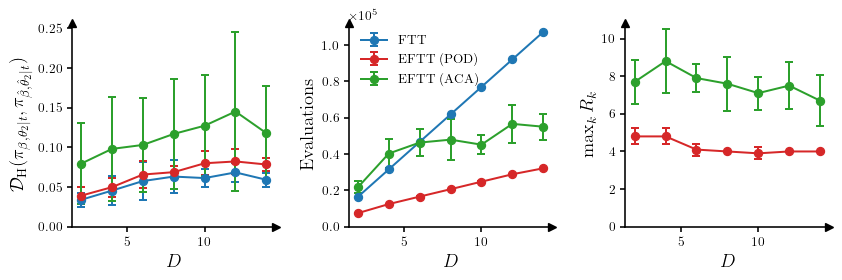

In [ ]:
#| code-fold: true
#| fig-align: center
#| fig-cap: Estimates of the Hellinger distance between the posterior and the DIRT approximation (left), the total number of target density evaluations (centre) and the maximum reduced basis rank (right) for the shock absorber inference problem with varying numbers of covariates, $D$, when different FTT representations are used.
#| label: fig-dimension

colours = ["tab:blue", "tab:red", "tab:green"]

kwargs_errorbar = {
    "fmt": "-o", "markersize": 6, 
    "linewidth": 1.5, "elinewidth": 1.5, 
    "capsize": 3.0, "capthick": 1.5
}

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))

dhells_mean = dhells.mean(dim=1)
dhells_sd = dhells.std(dim=1)

evals_mean = evals.mean(dim=1)
evals_sd = evals.std(dim=1)

max_tuckers_mean = max_tuckers.mean(dim=1)
max_tuckers_sd = max_tuckers.std(dim=1)

for i in range(len(ftts)):
    axes[0].errorbar(
        Ds, dhells_mean[:, i], yerr=dhells_sd[:, i], 
        label=ftts[i], c=colours[i], **kwargs_errorbar
    )
    axes[1].errorbar(
        Ds, evals_mean[:, i], yerr=evals_sd[:, i], 
        label=ftts[i], c=colours[i], **kwargs_errorbar
    )
    if "EFTT" in ftts[i]:
        axes[2].errorbar(
            Ds, max_tuckers_mean[:, i], yerr=max_tuckers_sd[:, i],
            label=ftts[i], c=colours[i], **kwargs_errorbar
        )

for ax in axes.flat:
    add_arrows(ax)
    ax.set_box_aspect(1)
    ax.set_xlabel(r"$D$")
    ax.set_ylim(bottom=0.0)

axes[0].set_ylabel(r"$\mathcal{D}_{\mathrm{H}}(\pi_{\beta, \theta_{2} | t}, \pi_{\hat{\beta}, \hat{\theta}_{2} | t})$")
axes[1].set_ylabel(r"Evaluations")
axes[2].set_ylabel(r"$\max_{k} R_{k}$")
axes[1].legend(fontsize=10)
axes[1].ticklabel_format(axis="y", scilimits=(0, 0))

plt.tight_layout()

save_path = plot_path.joinpath("dims.pdf").resolve()
plt.savefig(save_path)

## (E)FTT Comparison: Tensor Train Ranks

Next, we fix the number of covariates to $D = 8$ and vary the tensor train ranks. Again, we compare the DIRT approximations to the posterior constructed using the same (E)FTT approximations considered previously.

In [ ]:
D = 8
dim = D + 2

ms = torch.zeros(D+1)
ms[0] = math.log(30796)
sds = torch.ones(D+1)
sds[0] = math.sqrt(0.1563)

bounds = torch.zeros((D+2, 2))
bounds[:-1] = torch.vstack((ms - 3.0*sds, ms + 3.0*sds)).T 
bounds[-1] = torch.tensor([1e-8, 13.0])

preconditioner = GammaNormalMapping(
    reference, bounds, 
    alpha, gamma, 
    ms, sds, dim
)

ranks = [6, 8, 10, 12, 14, 16, 18, 20]                                  # <1>

1. Define ranks to test; these correspond to the max ranks after two cross approximation iterations using AMEn (with `kick_rank=2`)

In [ ]:
num_replications = 10
num_samples = 5000

dhells = torch.zeros((len(ranks), num_replications, len(ftts)))
evals = torch.zeros_like(dhells)

In [ ]:
for i, rank in enumerate(ranks):

    for j in range(num_replications):
        
        covariate_shape = (failure_dists.numel(), D)                    # <1>
        xs = torch.randn(covariate_shape) / D
        eval_neglogpost = lambda params: _eval_neglogpost(params, xs)
        target_func = dt.TargetFunc(eval_neglogpost)

        rs = reference.random(n=num_samples, d=dim)                     # <2>

        for k, ftt_name in enumerate(ftts):

            tt_options = dt.TTOptions(
                tt_method="amen", max_als=2, init_rank=rank-4, 
                verbose=0
            )
            tt = dt.TT(tt_options)
            if ftt_name == "FTT":
                ftt = dt.FTT(basis, tt)
            elif ftt_name == "EFTT (POD)":
                ftt = dt.EFTT(basis, tt, eftt_pod_options)
            elif ftt_name == "EFTT (ACA)":
                ftt = dt.EFTT(basis, tt, eftt_aca_options)
            dirt = dt.DIRT(
                target_func, preconditioner, ftt, bridge,
                options=dirt_options
            )

            samples_dirt, potentials_dirt = dirt.eval_irt(rs)           # <3>
            potentials_true = eval_neglogpost(samples_dirt)             # <4>
            dhell = dt.estimate_dhell(potentials_dirt, potentials_true) # <5>

            dhells[i][j][k] = dhell 
            evals[i][j][k] = dirt.num_eval_construction

1. Sample a new set of covariates from a (rescaled) Gaussian and define a function that evaluates the associated negative log-posterior density
2. Generate a new set of samples from the reference density
3. Apply the inverse Rosenblatt transport to the samples from the reference such that they are distributed acccording to the current DIRT approximation to the posterior
4. Evaluate the negative logarithm of the true (unnormalised) posterior density
5. Estimate the Hellinger distance between the posterior and the DIRT approximation

We can now plot the results.

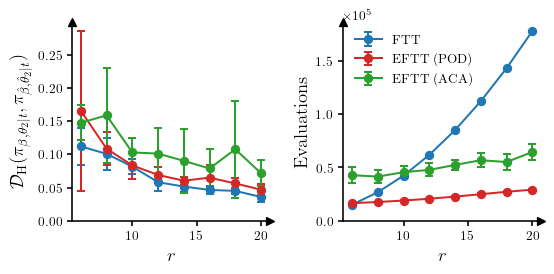

In [ ]:
#| code-fold: true
#| fig-align: center
#| fig-cap: Estimates of the Hellinger distance between the posterior and the DIRT approximation (left) and the total number of target density evaluations (right) for the shock absorber inference problem, when different FTT representations are used and the maximum tensor train rank $r$ is varied.
#| label: fig-ranks

fig, axes = plt.subplots(1, 2, figsize=(6, 3.2))

dhells_mean = dhells.mean(dim=1)
dhells_sd = dhells.std(dim=1)

evals_mean = evals.mean(dim=1)
evals_sd = evals.std(dim=1)

for i in range(len(ftts)):
    axes[0].errorbar(
        ranks, dhells_mean[:, i], yerr=dhells_sd[:, i], 
        label=ftts[i], c=colours[i], **kwargs_errorbar
    )
    axes[1].errorbar(
        ranks, evals_mean[:, i], yerr=evals_sd[:, i], 
        label=ftts[i], c=colours[i], **kwargs_errorbar
    )

for ax in axes.flat:
    add_arrows(ax)
    ax.set_box_aspect(1)
    ax.set_xlabel(r"$r$")
    ax.set_ylim(bottom=0.0)

axes[0].set_ylabel(r"$\mathcal{D}_{\mathrm{H}}(\pi_{\beta, \theta_{2} | t}, \pi_{\hat{\beta}, \hat{\theta}_{2} | t})$")
axes[1].set_ylabel(r"Evaluations")
axes[1].legend(fontsize=10)
axes[1].ticklabel_format(axis="y", scilimits=(0, 0))

plt.tight_layout()

save_path = plot_path.joinpath("ranks.pdf").resolve()
plt.savefig(save_path)